# Multicomponent test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *
from magE.functions import save_catalog

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J2212'
j2212 = pd.read_csv(galname + '.csv')

wave = j2212['wave'].to_numpy()
flux = j2212['flux'].to_numpy() * 1e17
err = j2212['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == galname)

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# [NII]6548 + Ha + [NII]6584
select = (wave > 7685) * (wave < 7780)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# [OIII]5007
select = (wave > 5875) * (wave < 5920)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5815) * (wave < 5860)
oiii_4959 = SpecPiece('oiii_4959', wave[select], flux[select], err[select])

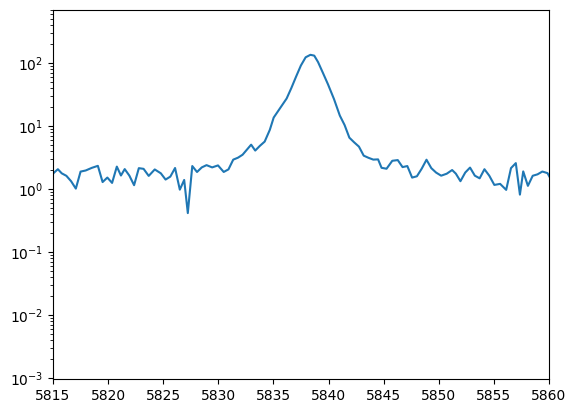

In [3]:
plt.plot(wave, flux)
plt.xlim(5815, 5860)
plt.yscale('log')

# Single gaussian component

## [OIII]4959

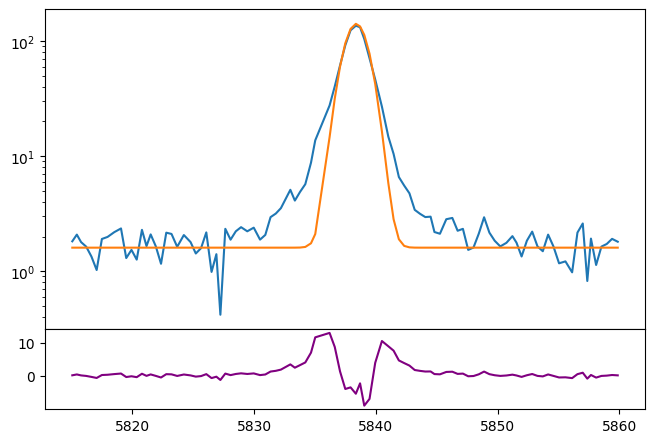

In [4]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 1.6

oiiib = gaussian(oiii_4959.wavelength, 350, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.0)

ax.plot(oiii_4959.wavelength, bkg + oiiib)
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib, color='purple')
ax.set_yscale('log')

In [5]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z', value=z_BN[igal])
params_oiii_4959.add('sigma', value=1.0, min=0.)
params_oiii_4959.add('Oiiib_flux', value=350, min=0.)
params_oiii_4959.add('bkg', value=1.6, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z = params_oiii_4959['z']
    sigma = params_oiii_4959['sigma']
    oiiib_flux = params_oiii_4959['Oiiib_flux']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_flux, wave_cat['[OIII]4959'], z, sigma)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [6]:
np.random.seed(2212)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:14<00:00, 169.37it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 36.44099653  86.36464713  52.83779477 118.6503879 ]


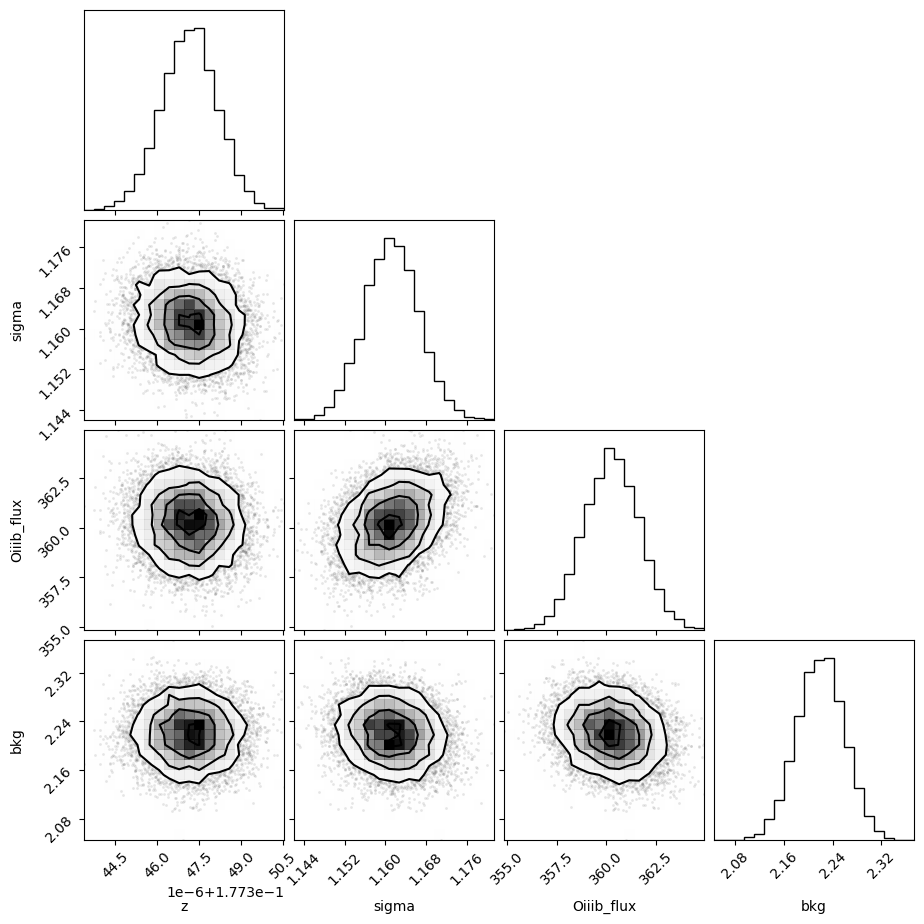

In [7]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [8]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.17734717,9.9248e-07,(0.00%),0.17735,-inf,inf,True
sigma,1.16124211,0.00530547,(0.46%),1.0,0.00000000,inf,True
Oiiib_flux,360.283538,1.41235302,(0.39%),350,0.00000000,inf,True
bkg,2.22062194,0.03878591,(1.75%),1.6,0.00000000,inf,True


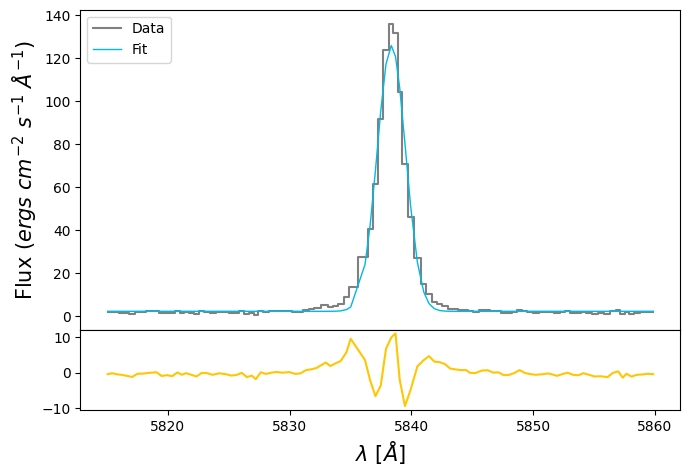

In [9]:
oiiib_flux = out_oiii_4959.flatchain.Oiiib_flux.mean()
oiiib_std = out_oiii_4959.flatchain.Oiiib_flux.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
z_oiii_4959 = out_oiii_4959.flatchain.z.mean()
sigma_oiii_4959 = out_oiii_4959.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib = gaussian(oiii_4959.wavelength, oiiib_flux, wave_cat['[OIII]4959'], z_oiii_4959, sigma_oiii_4959)

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [10]:
n_one = len(oiii_4959.flux)
k_one = out_oiii_4959.nvarys
log_likelihood_one = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
BIC_one = - (2 * log_likelihood_one) + (k_one * np.log(n_one))

In [11]:
BIC_one

1579.5321459655274

# Double component

## [OIII]4959

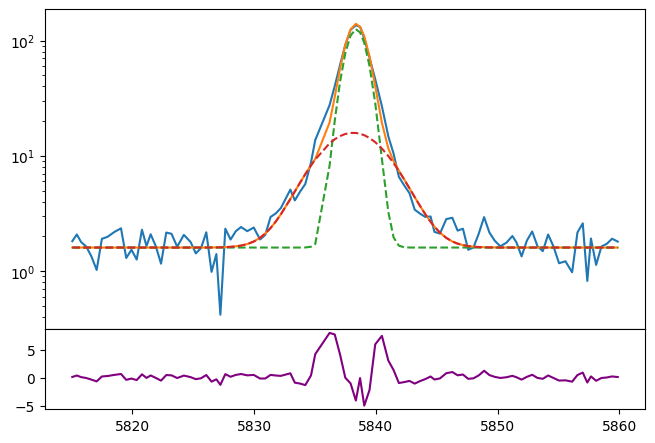

In [12]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 1.6

oiiib_nar = gaussian(oiii_4959.wavelength, 280, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.9)
oiiib_brd = gaussian(oiii_4959.wavelength, 100, wave_cat['[OIII]4959'], z=z_BN[igal]-0.00005, sigma=2.8)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [13]:
params2_oiii_4959 = Parameters()
params2_oiii_4959.add('z_nar', value=z_BN[igal])
params2_oiii_4959.add('z_brd', value=z_BN[igal]-0.00005)
params2_oiii_4959.add('sigma_nar', value=0.9, min=0.)
params2_oiii_4959.add('sigma_brd', value=2.8, min=0.)
params2_oiii_4959.add('Oiiib_nar', value=280, min=0.)
params2_oiii_4959.add('Oiiib_brd', value=100, min=0.)
params2_oiii_4959.add('bkg', value=1.6, min=0.)


def residual2_oiii_4959(params2_oiii_4959, x, data, uncertainty):
    
    z_nar = params2_oiii_4959['z_nar']
    z_brd = params2_oiii_4959['z_brd']
    sigma_nar = params2_oiii_4959['sigma_nar']
    sigma_brd = params2_oiii_4959['sigma_brd']
    oiiib_nar = params2_oiii_4959['Oiiib_nar']
    oiiib_brd = params2_oiii_4959['Oiiib_brd']
    bkg = params2_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [14]:
np.random.seed(2212)
out2_oiii_4959 = minimize(residual2_oiii_4959, params2_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 133.23it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [110.27998546  53.77934512 216.50638716 220.18119135 233.20999824
 233.51741889 171.92150658]


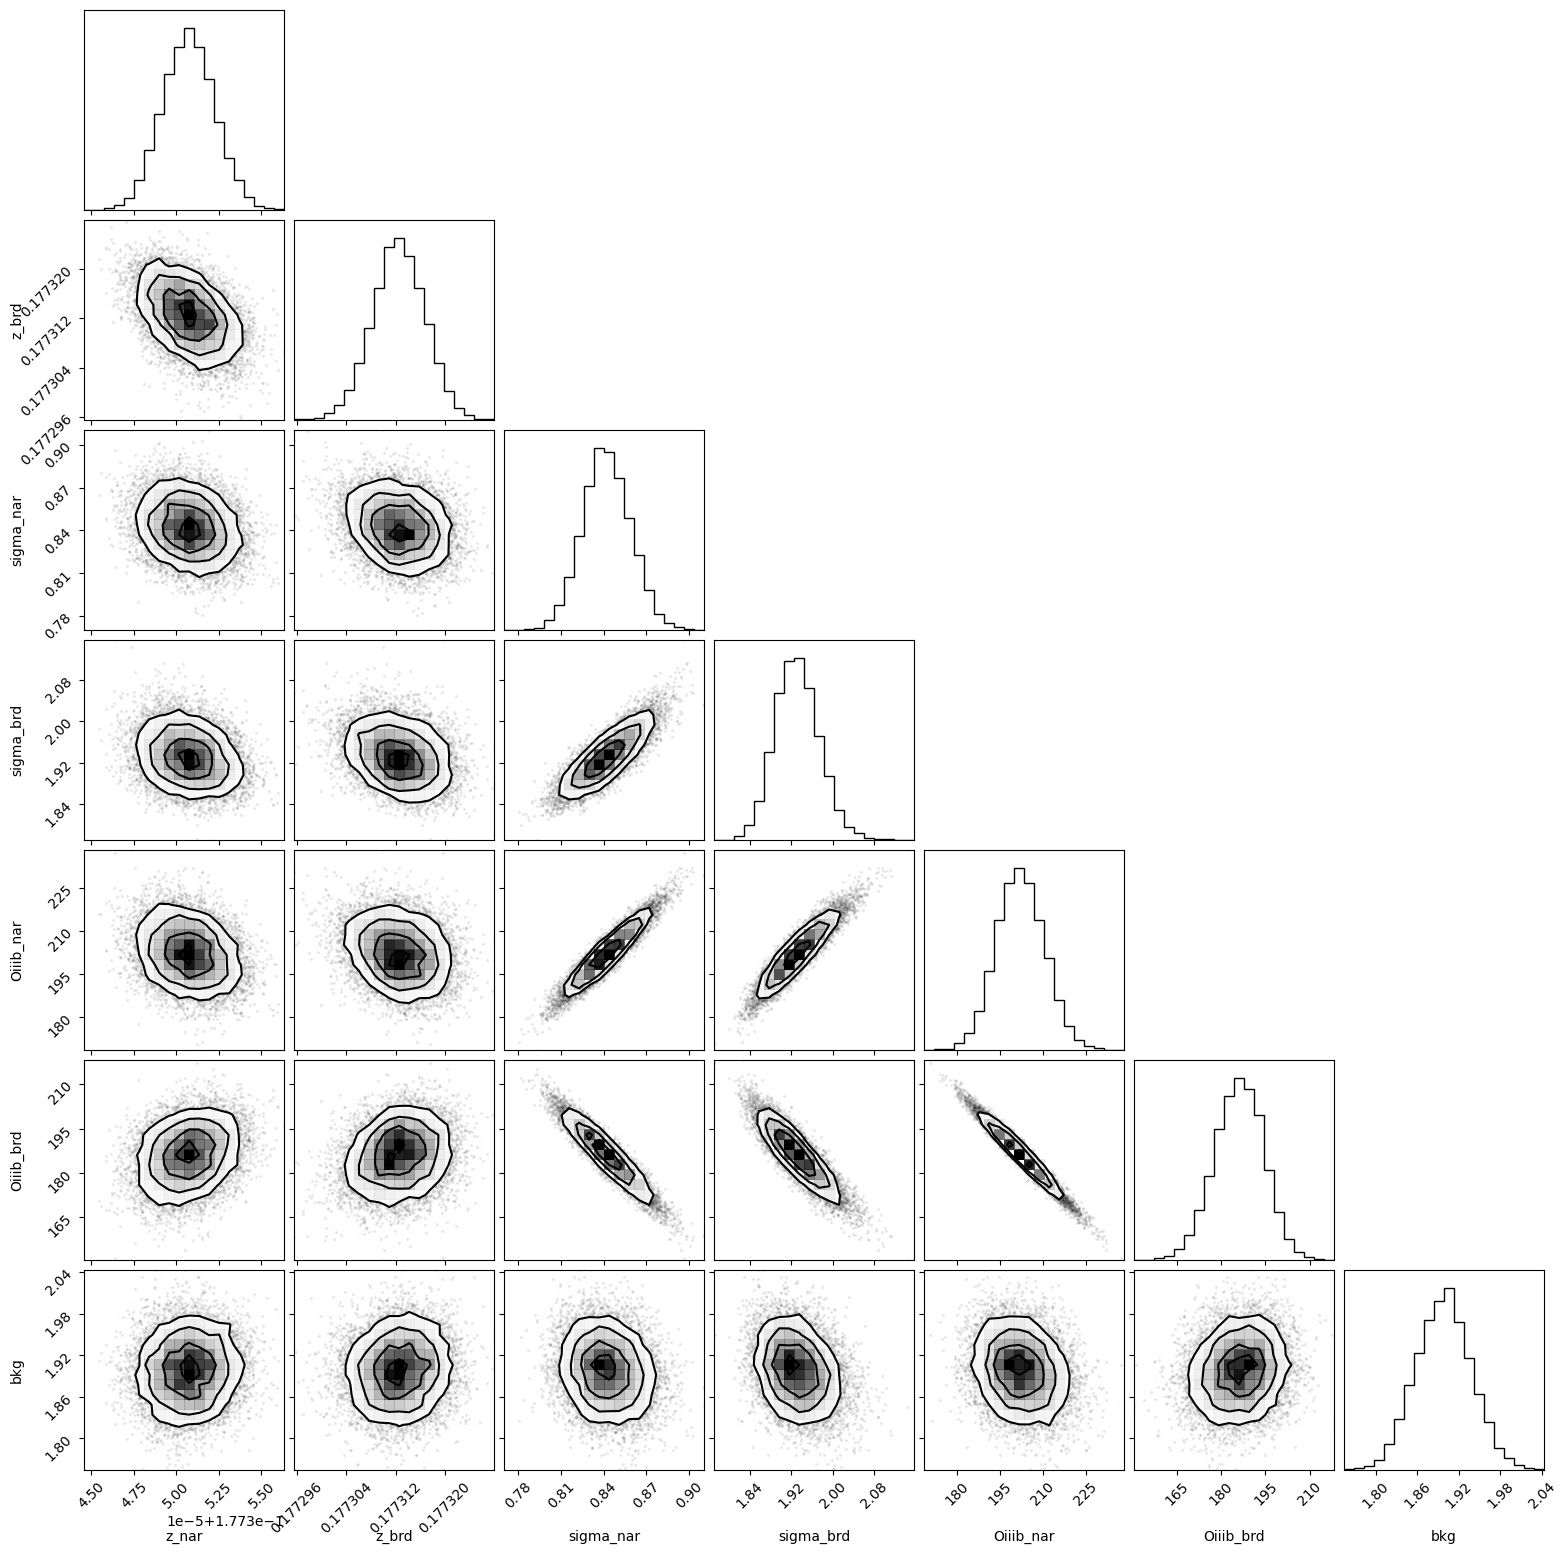

In [15]:
corner.corner(out2_oiii_4959.flatchain, labels=out2_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [16]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17735071,1.5356e-06,(0.00%),0.17735,-inf,inf,True
z_brd,0.17731256,4.2685e-06,(0.00%),0.1773,-inf,inf,True
sigma_nar,0.84184624,0.01673724,(1.99%),0.9,0.00000000,inf,True
sigma_brd,1.93013732,0.04242182,(2.20%),2.8,0.00000000,inf,True
Oiiib_nar,202.086332,8.29881173,(4.11%),280,0.00000000,inf,True
Oiiib_brd,186.316871,8.22282241,(4.41%),100,0.00000000,inf,True
bkg,1.89838055,0.04011304,(2.11%),1.6,0.00000000,inf,True


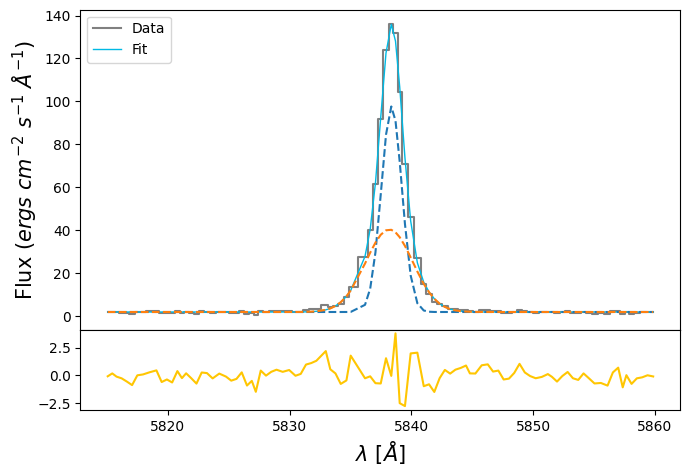

In [17]:
oiiib_nar_flux = out2_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out2_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out2_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out2_oiii_4959.flatchain.Oiiib_brd.std()

bkg2_oiii_4959 = out2_oiii_4959.flatchain.bkg.mean()

z_nar_oiii_4959 = out2_oiii_4959.flatchain.z_nar.mean()
z_brd_oiii_4959 = out2_oiii_4959.flatchain.z_brd.mean()

sigma_nar_oiii_4959 = out2_oiii_4959.flatchain.sigma_nar.mean()
sigma_brd_oiii_4959 = out2_oiii_4959.flatchain.sigma_brd.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg2_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [18]:
n_two = len(oiii_4959.flux)
k_two = out2_oiii_4959.nvarys
log_likelihood_two = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg2_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
BIC_two = - (2 * log_likelihood_two) + (k_two * np.log(n_two))

In [19]:
BIC_two

315.84969826887277

# Triple component

## [OIII]4959

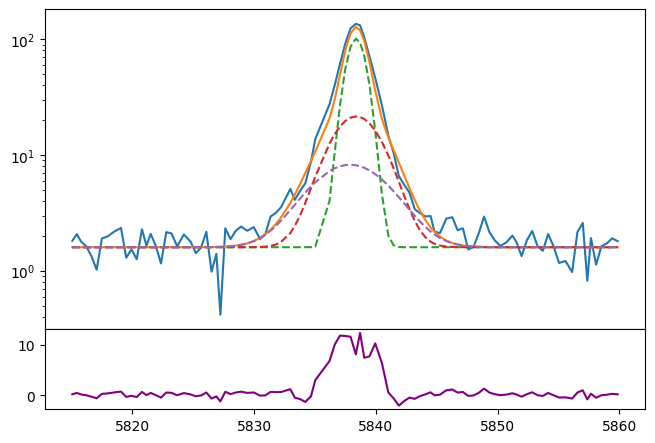

In [20]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 1.6

oiiib_nar = gaussian(oiii_4959.wavelength, 200, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=0.8)
oiiib_mid = gaussian(oiii_4959.wavelength, 100, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=2)
oiiib_brd = gaussian(oiii_4959.wavelength, 50, wave_cat['[OIII]4959'], z=z_BN[igal]-0.0001, sigma=3)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd + oiiib_mid)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_mid, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_mid - oiiib_brd, color='purple')
ax.set_yscale('log')

In [21]:
params3_oiii_4959 = Parameters()
params3_oiii_4959.add('z_nar', value=z_BN[igal])
params3_oiii_4959.add('z_mid', value=z_BN[igal])
params3_oiii_4959.add('z_brd', value=z_BN[igal])
params3_oiii_4959.add('sigma_nar', value=0.8, min=0.)
params3_oiii_4959.add('sigma_mid', value=2.0, min=0.)
params3_oiii_4959.add('sigma_brd', value=3.0, min=0.)
params3_oiii_4959.add('Oiiib_nar', value=200, min=0.)
params3_oiii_4959.add('Oiiib_mid', value=100, min=0.)
params3_oiii_4959.add('Oiiib_brd', value=50, min=0.)
params3_oiii_4959.add('bkg', value=1.6, min=0.)


def residual3_oiii_4959(params3_oiii_4959, x, data, uncertainty):
    
    z_nar = params3_oiii_4959['z_nar']
    z_mid = params3_oiii_4959['z_mid']
    z_brd = params3_oiii_4959['z_brd']
    
    sigma_nar = params3_oiii_4959['sigma_nar']
    sigma_mid = params3_oiii_4959['sigma_mid']
    sigma_brd = params3_oiii_4959['sigma_brd']
    
    oiiib_nar = params3_oiii_4959['Oiiib_nar']
    oiiib_mid = params3_oiii_4959['Oiiib_mid']
    oiiib_brd = params3_oiii_4959['Oiiib_brd']
    
    bkg = params3_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_mid, wave_cat['[OIII]4959'], z_mid, sigma_mid) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [22]:
np.random.seed(2212)
out3_oiii_4959 = minimize(residual3_oiii_4959, params3_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:21<00:00, 114.05it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 10 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 88.30565558  75.57603324  66.37940332 250.16985395 243.14134513
 143.85851789 264.19304676 273.3202929   82.59177198 113.03467215]


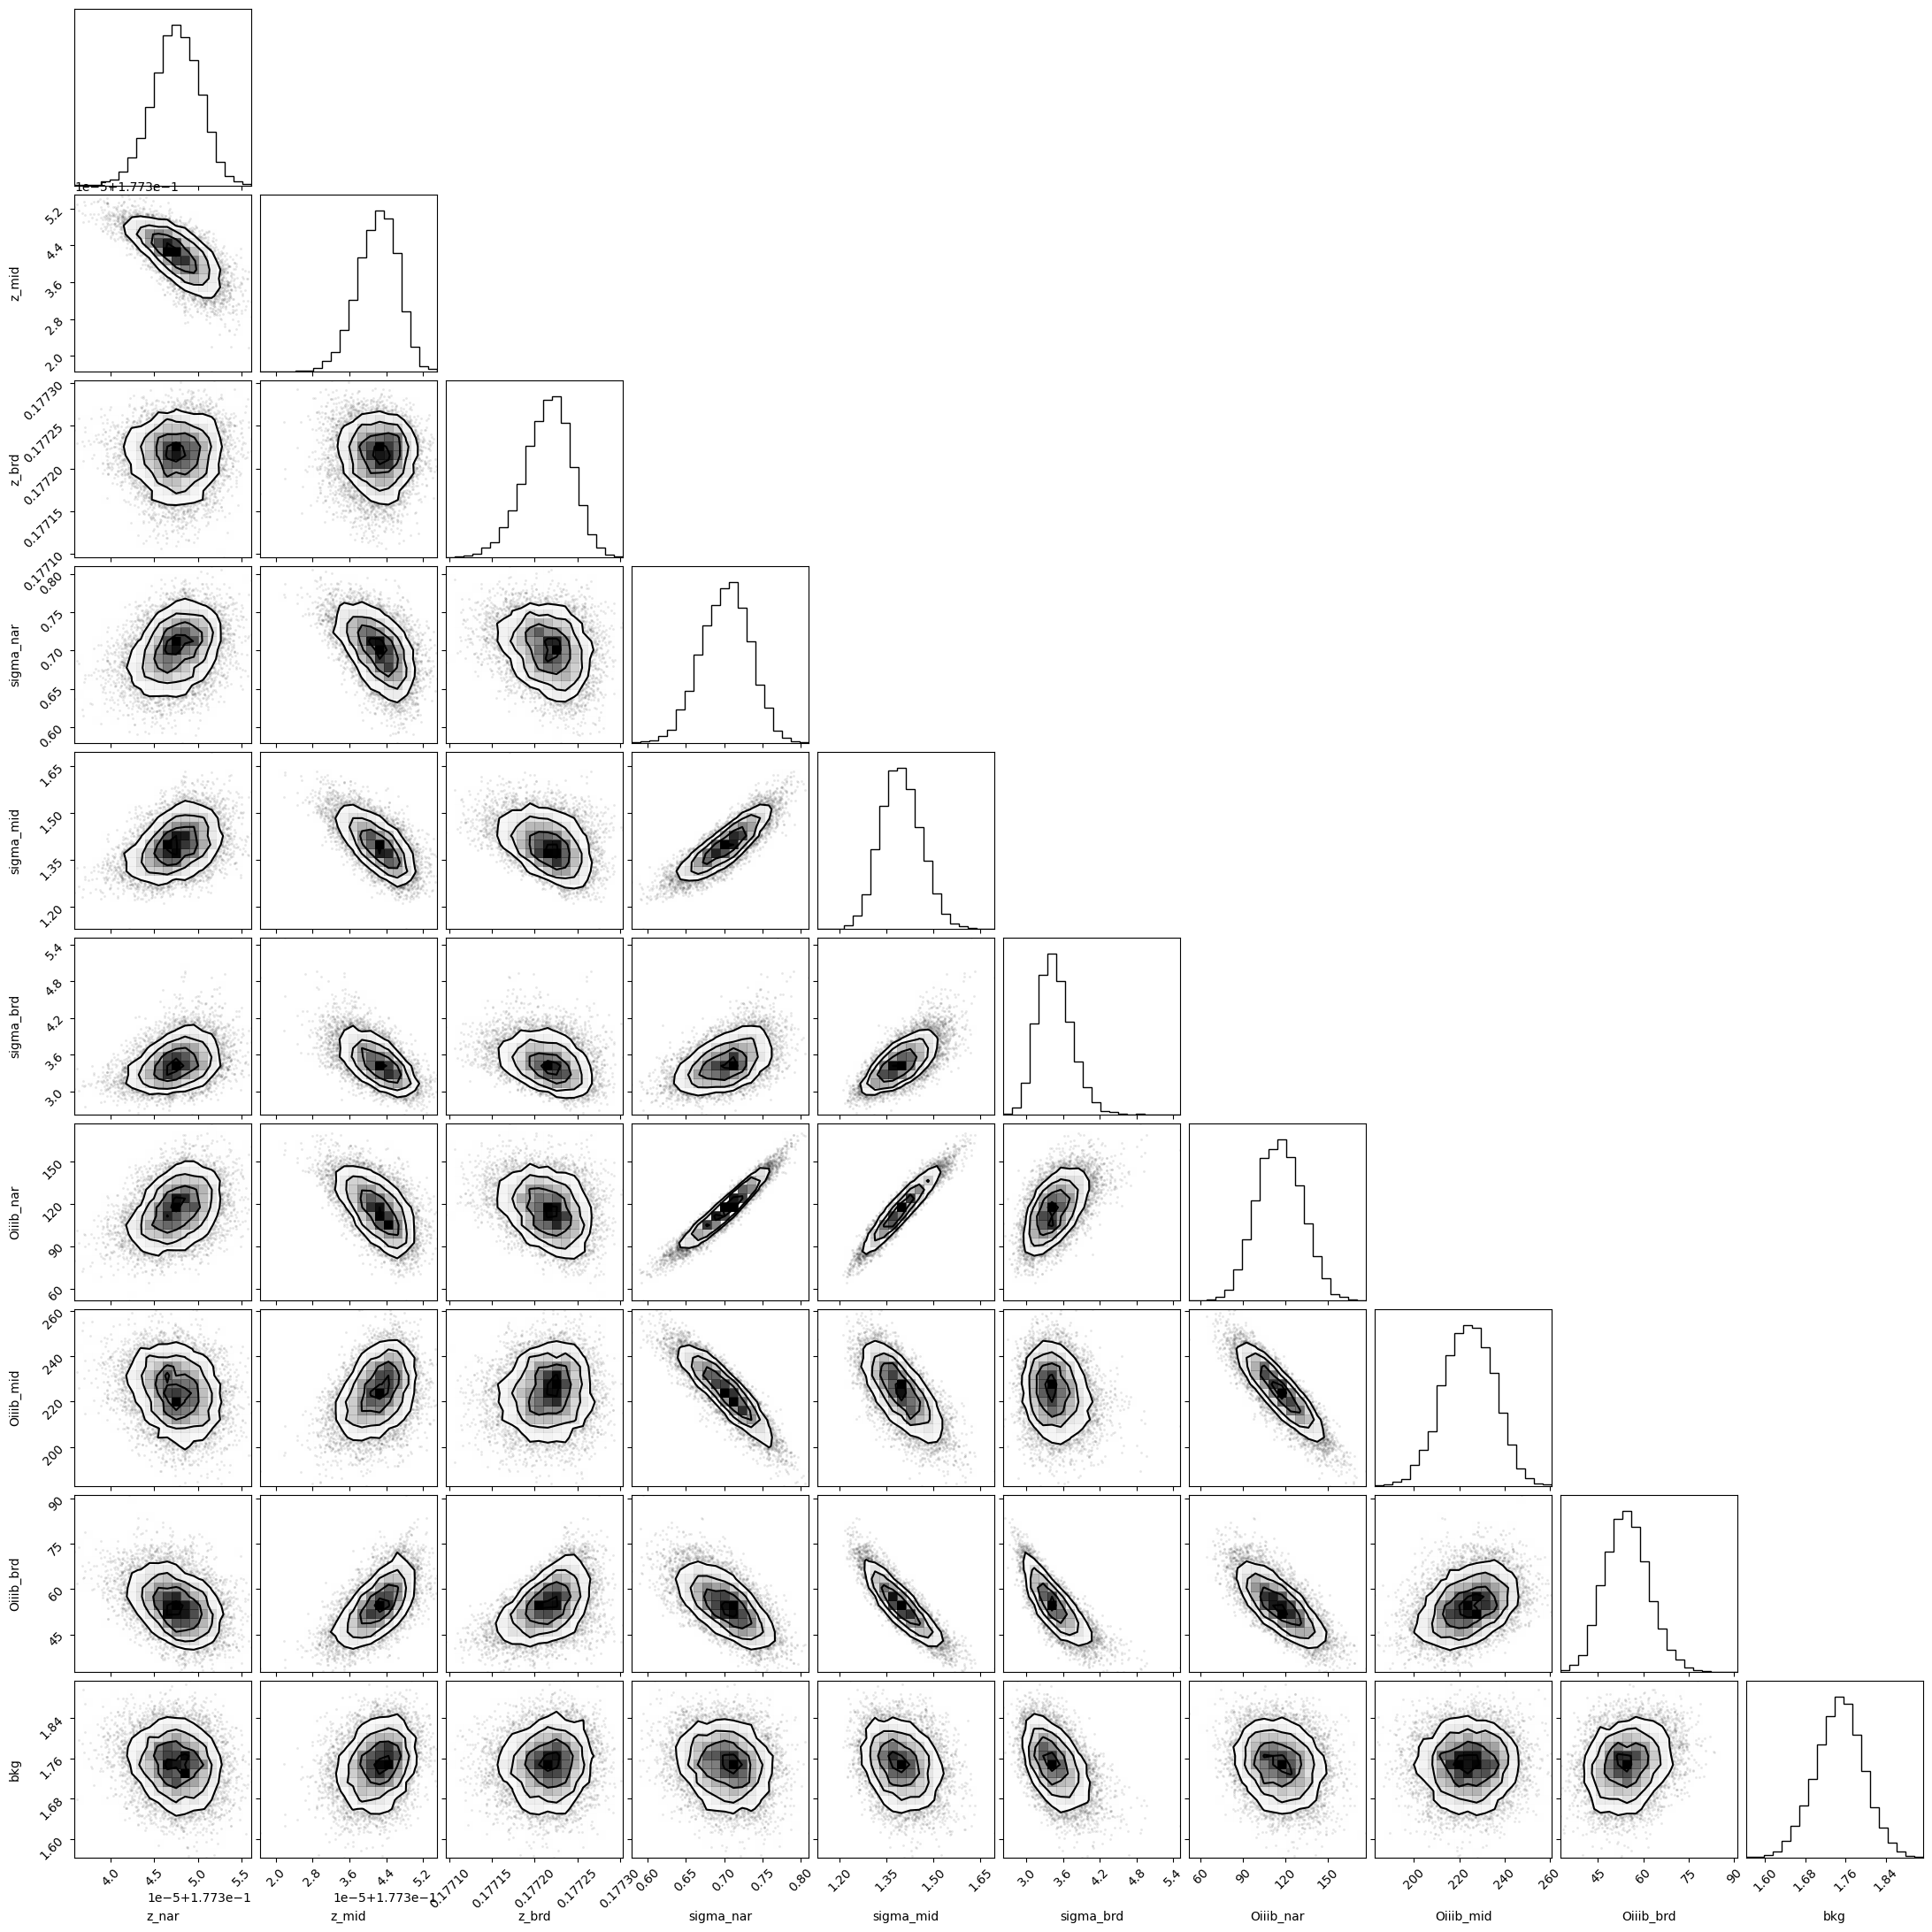

In [23]:
corner.corner(out3_oiii_4959.flatchain, labels=out3_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [24]:
out3_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.17734758,2.6775e-06,(0.00%),0.17735,-inf,inf,True
z_mid,0.17734233,4.3110e-06,(0.00%),0.17735,-inf,inf,True
z_brd,0.17721693,2.7211e-05,(0.02%),0.17735,-inf,inf,True
sigma_nar,0.70279390,0.03197611,(4.55%),0.8,0.00000000,inf,True
sigma_mid,1.39346115,0.06447956,(4.63%),2.0,0.00000000,inf,True
sigma_brd,3.43857536,0.27639956,(8.04%),3.0,0.00000000,inf,True
Oiiib_nar,115.633438,16.1077073,(13.93%),200,0.00000000,inf,True
Oiiib_mid,224.400891,11.2885453,(5.03%),100,0.00000000,inf,True
Oiiib_brd,54.4423931,7.26056815,(13.34%),50,0.00000000,inf,True
bkg,1.74881968,0.04730749,(2.71%),1.6,0.00000000,inf,True


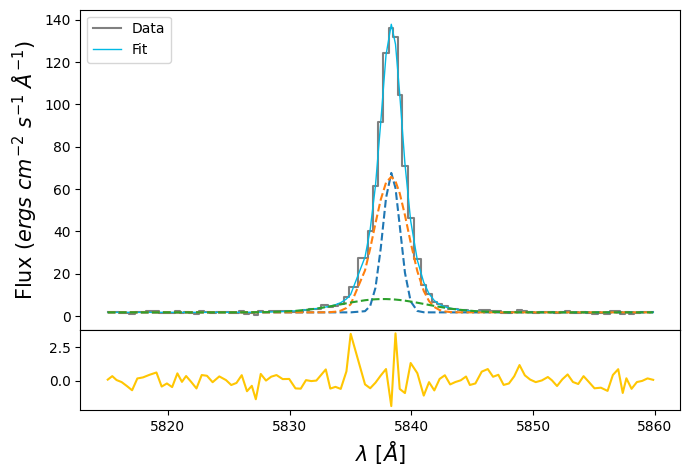

In [25]:
oiiib_nar_flux = out3_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out3_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_mid_flux = out3_oiii_4959.flatchain.Oiiib_mid.mean()
oiiib_mid_std = out3_oiii_4959.flatchain.Oiiib_mid.std()

oiiib_brd_flux = out3_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out3_oiii_4959.flatchain.Oiiib_brd.std()

bkg3_oiii_4959 = out3_oiii_4959.flatchain.bkg.mean()

z_nar_oiii_4959 = out3_oiii_4959.flatchain.z_nar.mean()
z_mid_oiii_4959 = out3_oiii_4959.flatchain.z_mid.mean()
z_brd_oiii_4959 = out3_oiii_4959.flatchain.z_brd.mean()

sigma_nar_oiii_4959 = out3_oiii_4959.flatchain.sigma_nar.mean()
sigma_mid_oiii_4959 = out3_oiii_4959.flatchain.sigma_mid.mean()
sigma_brd_oiii_4959 = out3_oiii_4959.flatchain.sigma_brd.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_mid = gaussian(oiii_4959.wavelength, oiiib_mid_flux, wave_cat['[OIII]4959'], z_mid_oiii_4959, sigma_mid_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_mid + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_mid, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg3_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [26]:
n_three = len(oiii_4959.flux)
k_three = out3_oiii_4959.nvarys
log_likelihood_three = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg3_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
BIC_three = - (2 * log_likelihood_three) + (k_three * np.log(n_three))

In [27]:
BIC_three

223.37479236474414

# $\Delta$BIC

In [28]:
print('dBIC = BIC_one - BIC_two (LMFIT):', round(out_oiii_4959.bic - out2_oiii_4959.bic, 3))
print('dBIC = BIC_one - BIC_two (My BIC):', round(BIC_one - BIC_two, 3))

dBIC = BIC_one - BIC_two (LMFIT): 157.852
dBIC = BIC_one - BIC_two (My BIC): 1263.682


In [29]:
print('dBIC = BIC_two - BIC_three (LMFIT):', round(out2_oiii_4959.bic - out3_oiii_4959.bic, 3))
print('dBIC = BIC_two - BIC_three (My BIC):', round(BIC_two - BIC_three, 3))

dBIC = BIC_two - BIC_three (LMFIT): 33.296
dBIC = BIC_two - BIC_three (My BIC): 92.475


# Plot

Text(0.5, 1.0, '$\\Delta$BIC$_{2-3}$ = 33.3')

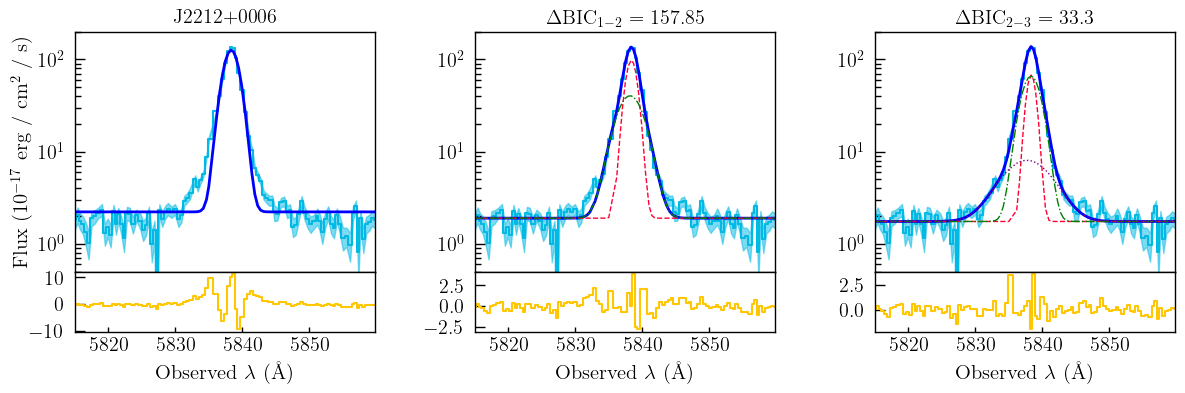

In [30]:
texPlot('on')

fig = plt.figure()
fig.set_size_inches(10, 3)

ax00 = fig.add_axes((0, .2, .3, .8))
ax10 = fig.add_axes((0, 0, .3, .2))

ax01 = fig.add_axes((.4, .2, .3, .8))
ax11 = fig.add_axes((.4, 0, .3, .2))

ax02 = fig.add_axes((.8, .2, .3, .8))
ax12 = fig.add_axes((.8, 0, .3, .2))

ax00.set_ylabel(r'Flux (10$^{-17}$ erg / cm$^{2}$ / s)', fontsize=15)
ax10.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)
ax11.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)
ax12.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)

ax00.set_xticks([])
ax01.set_xticks([])
ax02.set_xticks([])

ax00.tick_params(axis='y', direction='in', which='both')
ax01.tick_params(axis='y', direction='in', which='both')
ax02.tick_params(axis='y', direction='in', which='both')

ax10.tick_params(axis='both', direction='in', which='both')
ax11.tick_params(axis='both', direction='in', which='both')
ax12.tick_params(axis='both', direction='in', which='both')

ax00.set_yscale('log')
ax01.set_yscale('log')
ax02.set_yscale('log')

# Single component
oiiib_flux = out_oiii_4959.flatchain.Oiiib_flux.mean()
oiiib_std = out_oiii_4959.flatchain.Oiiib_flux.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
z_oiii_4959 = out_oiii_4959.flatchain.z.mean()
sigma_oiii_4959 = out_oiii_4959.flatchain.sigma.mean()

oiiib_single = gaussian(oiii_4959.wavelength, oiiib_flux, wave_cat['[OIII]4959'], z_oiii_4959, sigma_oiii_4959)

ax00.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax00.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)

ax00.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_single,
        lw=2, color='Blue', label='Best-fit')
ax10.step(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib_single,
         color=c[3], where='mid')

# Double component

oiiib2_nar_flux = out2_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib2_nar_std = out2_oiii_4959.flatchain.Oiiib_nar.std()

oiiib2_brd_flux = out2_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib2_brd_std = out2_oiii_4959.flatchain.Oiiib_brd.std()

bkg2_oiii_4959 = out2_oiii_4959.flatchain.bkg.mean()

z2_nar_oiii_4959 = out2_oiii_4959.flatchain.z_nar.mean()
z2_brd_oiii_4959 = out2_oiii_4959.flatchain.z_brd.mean()

sigma2_nar_oiii_4959 = out2_oiii_4959.flatchain.sigma_nar.mean()
sigma2_brd_oiii_4959 = out2_oiii_4959.flatchain.sigma_brd.mean()

oiiib2_nar = gaussian(oiii_4959.wavelength, oiiib2_nar_flux, wave_cat['[OIII]4959'], z2_nar_oiii_4959, sigma2_nar_oiii_4959)
oiiib2_brd = gaussian(oiii_4959.wavelength, oiiib2_brd_flux, wave_cat['[OIII]4959'], z2_brd_oiii_4959, sigma2_brd_oiii_4959)
oiiib2 = oiiib2_nar + oiiib2_brd

ax01.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax01.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2,
        lw=2, color='blue', label='Best-fit')
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2_nar, ls='--', lw=1, color=c[1])
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2_brd, ls='-.', lw=1, color='green')
ax11.step(oiii_4959.wavelength, oiii_4959.flux - bkg2_oiii_4959 - oiiib2,
         color=c[3], where='mid')

# Triple component

oiiib3_nar_flux = out3_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib3_nar_std = out3_oiii_4959.flatchain.Oiiib_nar.std()

oiiib3_mid_flux = out3_oiii_4959.flatchain.Oiiib_mid.mean()
oiiib3_mid_std = out3_oiii_4959.flatchain.Oiiib_mid.std()

oiiib3_brd_flux = out3_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib3_brd_std = out3_oiii_4959.flatchain.Oiiib_brd.std()

bkg3_oiii_4959 = out3_oiii_4959.flatchain.bkg.mean()

z3_nar_oiii_4959 = out3_oiii_4959.flatchain.z_nar.mean()
z3_mid_oiii_4959 = out3_oiii_4959.flatchain.z_mid.mean()
z3_brd_oiii_4959 = out3_oiii_4959.flatchain.z_brd.mean()

sigma3_nar_oiii_4959 = out3_oiii_4959.flatchain.sigma_nar.mean()
sigma3_mid_oiii_4959 = out3_oiii_4959.flatchain.sigma_mid.mean()
sigma3_brd_oiii_4959 = out3_oiii_4959.flatchain.sigma_brd.mean()

oiiib3_nar = gaussian(oiii_4959.wavelength, oiiib3_nar_flux, wave_cat['[OIII]4959'], z3_nar_oiii_4959, sigma3_nar_oiii_4959)
oiiib3_mid = gaussian(oiii_4959.wavelength, oiiib3_mid_flux, wave_cat['[OIII]4959'], z3_mid_oiii_4959, sigma3_mid_oiii_4959)
oiiib3_brd = gaussian(oiii_4959.wavelength, oiiib3_brd_flux, wave_cat['[OIII]4959'], z3_brd_oiii_4959, sigma3_brd_oiii_4959)
oiiib3 = oiiib3_nar + oiiib3_mid + oiiib3_brd

ax02.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax02.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)

ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3,
        lw=2, color='blue', label='Total')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_nar, ls='--', lw=1, color=c[1], label='Narrow')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_mid, ls='-.', lw=1, color='green', label='Mid-width')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_brd, ls=':', lw=1, color='purple', label='Broad')
ax12.step(oiii_4959.wavelength, oiii_4959.flux - bkg3_oiii_4959 - oiiib3,
         color=c[3], where='mid')
#ax02.legend(fontsize=10, loc=(-2.05, 0.55))

ax00.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax01.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax02.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax10.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax11.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax12.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))

ax00.set_ylim(0.5, 2e2)
ax01.set_ylim(0.5, 2e2)
ax02.set_ylim(0.5, 2e2)

ax00.set_title('J2212+0006')
ax01.set_title(r'$\Delta$BIC$_{1-2}$'+' = {:.7}'.format(round(out_oiii_4959.bic - out2_oiii_4959.bic, 2)))
ax02.set_title(r'$\Delta$BIC$_{2-3}$'+' = {:.7}'.format(round(out2_oiii_4959.bic - out3_oiii_4959.bic, 2)))
#fig.savefig(magePath+'imges/comp_test/J2212.pdf', bbox_inches='tight');

In [31]:
bic_dict = {'galname': galname,
            'BIC_1_2': out_oiii_4959.bic - out2_oiii_4959.bic,
            'BIC_2_3': out2_oiii_4959.bic - out3_oiii_4959.bic
}

In [32]:
bic_dict_pd = pd.DataFrame(data=bic_dict, index=[0])
save_catalog(galname, bic_dict_pd, magePath + '/results/comp_test.csv')

Existent catalog (.csv) file.
Non existent data for J2212, adding new data...
Done.
